Основные цели:
1. Понять поведение клиентов и транзакций банка
2. Выявить факторы, связанные с мошенническими транзакциями
3. Сегментировать клиентов по финансовому поведению

Основные вопросы:
1. Как распределяются суммы транзакций?
2. Есть ли сезонность транзакций?
3. Какие категории трат самые популярные?
4. Какие клиенты совершают больше всего транзакций?
5. Есть ли паттерны мошеннических операций?
6. Какие факторы связаны с fraud?

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/mcc_codes.json
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/users_data.csv
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/transactions_data.csv
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/cards_data.csv
/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/train_fraud_labels.json


In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Подробные записи о транзакциях
# path = '/content/drive/MyDrive/Colab Notebooks/fin/transactions_data.csv'
path = '/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/transactions_data.csv'
data = pd.read_csv(path)
fp_shape = [data.shape[0], data.shape[1]]

In [ ]:
# Данные о кредитных и дебетовых картах
path_cards = '/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/cards_data.csv'
# path_cards = '/content/drive/MyDrive/Colab Notebooks/fin/cards_data.csv'
cards_data = pd.read_csv(path_cards)

# Пользовательские данные
path_users = '/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/users_data.csv'
# path_users = '/content/drive/MyDrive/Colab Notebooks/fin/users_data.csv'
users_data = pd.read_csv(path_users)

# Коды классификации видов деятельности
path_mcc_codes = '/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/mcc_codes.json'
# path_mcc_codes = '/content/drive/MyDrive/Colab Notebooks/fin/mcc_codes.json'
read_mcc_codes = pd.read_json(path_mcc_codes, typ='series')  # frame series
data_mcc_codes = read_mcc_codes.rename("description").reset_index().rename(columns={"index": "mcc"})
data_mcc_codes["mcc"] = data_mcc_codes["mcc"].astype(int)

# Метки о мошенничестве
path_fraud_labels = '/kaggle/input/datasets/computingvictor/transactions-fraud-datasets/train_fraud_labels.json'
# path_fraud_labels = '/content/drive/MyDrive/Colab Notebooks/fin/train_fraud_labels.json'
data_fraud_labels = pd.read_json(path_fraud_labels)
data_fraud_labels.reset_index(inplace= True)
data_fraud_labels.columns = ["id" , "fraud_flag"]

In [ ]:
data.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [ ]:
data.isna().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state     1563700
zip                1652706
mcc                      0
errors            13094522
dtype: int64

**Обработка значений в столбцах**

In [ ]:
# Удаление $ в amount
data['amount'] = data['amount'].str.replace("$", "").astype("float")

In [ ]:
# Обработка значений в merchant_state
# data['merchant_state'].info(), data['merchant_state'].describe(), data['merchant_state'].unique(), data['merchant_state'].value_counts() , data[data["merchant_state"].isna()]
data['merchant_state'].fillna('None_flag', inplace=True)

/tmp/ipykernel_55/1373051242.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['merchant_state'].fillna('None_flag', inplace=True)


In [ ]:
data.isna().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state           0
zip                1652706
mcc                      0
errors            13094522
dtype: int64

In [ ]:
# Обработка значений в errors
# data[data["errors"].isna()]
data['errors'].fillna('No_errors', inplace=True)

/tmp/ipykernel_55/3211593820.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['errors'].fillna('No_errors', inplace=True)


In [ ]:
data.isna().sum()

id                      0
date                    0
client_id               0
card_id                 0
amount                  0
use_chip                0
merchant_id             0
merchant_city           0
merchant_state          0
zip               1652706
mcc                     0
errors                  0
dtype: int64

In [ ]:
# Заполенение меток zip
# Опечатки в бд
city_filled = {
  "Abu Dhabi": "00000",
  "Abuja": "900001",
  "Acapulco": "39300",
  "Accra": "00233",
  "Addis Ababa": "1000",
  "Algiers": "16000",
  "Amman": "11118",
  "Amsterdam": "1011",
  "Andorra La Vella": "AD500",
  "Apia": "00000",
  "Asmara": "00000",
  "Athens": "10552",
  "Baghdad": "10001",
  "Baku": "AZ1000",
  "Bamako": "00000",
  "Bandar Seri Begawan": "BA1111",
  "Bangalore": "560001",
  "Bangkok": "10200",
  "Barcelona": "08001",
  "Beijing": "100000",
  "Beirut": "1107",
  "Belgrade": "11000",
  "Belmopan": "00000",
  "Berlin": "10115",
  "Bishek": "720001",
  "Bogota": "110111",
  "Bratislava": "811 01",
  "Brazzaville": "00000",
  "Bridgetown": "BB11114",
  "Brussels": "1000",
  "Bucharest": "010011",
  "Budapest": "1051",
  "Buenos Aires": "C1000",
  "Cabo San Lucas": "23450",
  "Cairo": "11511",
  "Calgary": "T2P",
  "Cancun": "77500",
  "Caracas": "1010",
  "Chisinau": "MD-2001",
  "Colombo": "00100",
  "Conakry": "00000",
  "Copenhagen": "1050",
  "Dakar": "11000",
  "Delhi": "110001",
  "Dhaka": "1000",
  "Dili": "1000",
  "Doha": "00000",
  "Dublin": "D01",
  "Edinburgh": "EH1",
  "Edmonton": "T5J",
  "Freetown": "00000",
  "Funafuti": "00000",
  "Geneva": "1201",
  "Georgetown": "00000",
  "Guadalajara": "44100",
  "Guatamala City": "01001",
  "Hanoi": "100000",
  "Harare": "00000",
  "Helsinki": "00100",
  "Ho Chi Minh City": "700000",
  "Hong Kong": "999077",
  "Honiara": "00000",
  "Islamabad": "44000",
  "Istanbul": "34000",
  "Jakarta": "10110",
  "Jerusalem": "91000",
  "Johannesburg": "2000",
  "Juba": "00000",
  "Karachi": "74000",
  "Khartoum": "11111",
  "Kiev": "01001",
  "Kingston": "00000",
  "Kingstown": "VC0100",
  "Kolkata": "700001",
  "Kuala Lumpur": "50000",
  "Lahore": "54000",
  "Libreville": "00000",
  "Lima": "15001",
  "Lisbon": "1100-148",
  "Ljubljana": "1000",
  "London": "SW1A 1AA",
  "Lusaka": "10101",
  "Luxembourg": "L-1111",
  "Madrid": "28001",
  "Majuro": "96960",
  "Malabo": "00000",
  "Male": "20026",
  "Manama": "323",
  "Manila": "1000",
  "Maputo": "1100",
  "Mbabane": "H100",
  "Mexico City": "01000",
  "Monaco": "98000",
  "Monrovia": "1000",
  "Montevideo": "11000",
  "Montreal": "H3A",
  "Moscow": "101000",
  "Mumbai": "400001",
  "Muscat": "113",
  "Nairobi": "00100",
  "Nassau": "00000",
  "Niamey": "00000",
  "Nicosia": "1010",
  "Nuku Alofa": "00000",
  "Oranjestad": "00000",
  "Oslo": "0150",
  "Ouagadougou": "00000",
  "Palikir": "96941",
  "Panama City": "0819",
  "Paramaribo": "00000",
  "Paris": "75001",
  "Podgorica": "81000",
  "Port Moresby": "111",
  "Port Vila": "00000",
  "Port au Prince": "6110",
  "Port of Spain": "00000",
  "Porto-Novo": "00000",
  "Prague": "110 00",
  "Praia": "7600",
  "Pristina": "10000",
  "Puerto Vallarta": "48300",
  "Quito": "170101",
  "Rabat": "10000",
  "Reykjavik": "101",
  "Riga": "LV-1050",
  "Rio de Janeiro": "20000-000",
  "Riyadh": "12611",
  "Rome": "00184",
  "Saint John's": "00000",
  "Saint Petersburg": "190000",
  "San Jose": "10101",
  "Sanaa": "00000",
  "Santiago": "8320000",
  "Santo Domingo": "10101",
  "Sao Paulo": "01000-000",
  "Sarajevo": "71000",
  "Seoul": "04524",
  "Shanghai": "200000",
  "Singapore": "018989",
  "Skopje": "1000",
  "Stockholm": "11120",
  "Suva": "00000",
  "Sydney": "2000",
  "Tallinn": "10111",
  "Tapei": "100",
  "Tashkent": "100000",
  "Tblisi": "0105",
  "Tegucigalpa": "11101",
  "Tehran": "11369",
  "Tirana": "1001",
  "Tokyo": "100-0001",
  "Toronto": "M5H",
  "Tunis": "1000",
  "Ulan Bator": "15160",
  "Valletta": "VLT 1117",
  "Vancouver": "V5K",
  "Vatican City": "00120",
  "Victoria": "00000",
  "Vienna": "1010",
  "Vilnius": "01100",
  "Warsaw": "00-001",
  "Wellington": "6011",
  "Yamoussoukro": "00000",
  "Yangon": "11181",
  "Yaounde": "00000",
  "Yaren District": "00000",
  "Zagreb": "10000",
  "Zurich": "8001"
}
data["zip"] = data["zip"].fillna(data["merchant_city"].map(city_filled))
data['merchant_city'] = data['merchant_city'].str.replace("Johannesberg", "Johannesburg").astype("str")
data['merchant_city'] = data['merchant_city'].str.replace("Sao Paolo", "Sao Paulo").astype("str")
'''
# Вывод всех значений merchant_city, если zip = NaN
cities = data.loc[data["zip"].isna(), "merchant_city"].dropna().unique()
print(cities)
'''
# Флаг непонятного города
data.loc[data["merchant_city"] == "ONLINE", "zip"] = 0

'''
# Список городов и коды для некоторых из них
path_city = '/content/drive/MyDrive/Colab Notebooks/fin/city_filled.json'
data_city_codes = pd.read_json(path_city, typ='series')
data_city_codes = data_city_codes.rename("Codes").reset_index().rename(columns={"index": "City"})
data_city_codes["City"] = data_city_codes["City"]

# Заполняем zip только для NaN
city_to_zip = data_city_codes.set_index("City")["Codes"]
data["zip"] = data["zip"].fillna(data["merchant_city"].map(city_to_zip))
'''

'\n# Список городов и коды для некоторых из них\npath_city = \'/content/drive/MyDrive/Colab Notebooks/fin/city_filled.json\'\ndata_city_codes = pd.read_json(path_city, typ=\'series\')\ndata_city_codes = data_city_codes.rename("Codes").reset_index().rename(columns={"index": "City"})\ndata_city_codes["City"] = data_city_codes["City"]\n\n# Заполняем zip только для NaN\ncity_to_zip = data_city_codes.set_index("City")["Codes"]\ndata["zip"] = data["zip"].fillna(data["merchant_city"].map(city_to_zip))\n'

In [ ]:
data.isna().sum()

id                  0
date                0
client_id           0
card_id             0
amount              0
use_chip            0
merchant_id         0
merchant_city       0
merchant_state      0
zip               773
mcc                 0
errors              0
dtype: int64

***Визуализация данных***

In [ ]:
# Histogram суммы транзакции
# временные признаки
# дата
data['date'] = pd.to_datetime(data['date'], errors='coerce')
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['month_name'] = data['date'].dt.month_name()
data['weekday'] = data['date'].dt.day_name()
data['hour'] = data['date'].dt.hour

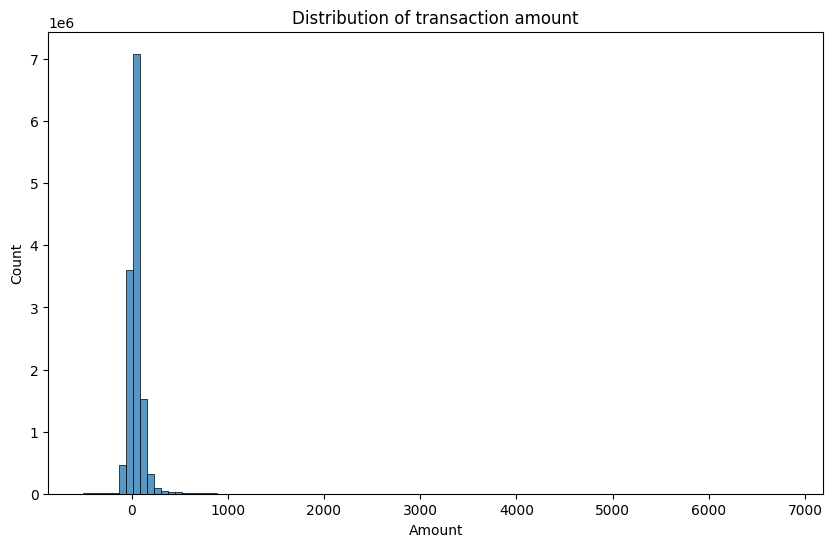

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='amount', bins=100)
plt.title('Distribution of transaction amount')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()

Вывод по графику :
1. Сильная асимметрия(есть выбросы в виде больших переводов и отрицательные переводы - возврат средств/отмененные операции)
2. Основная масса - маленькие суммы
3. Гистограмма "сжата" слева(в наборе возвраты средств только небольших перводов/небольших покупок)

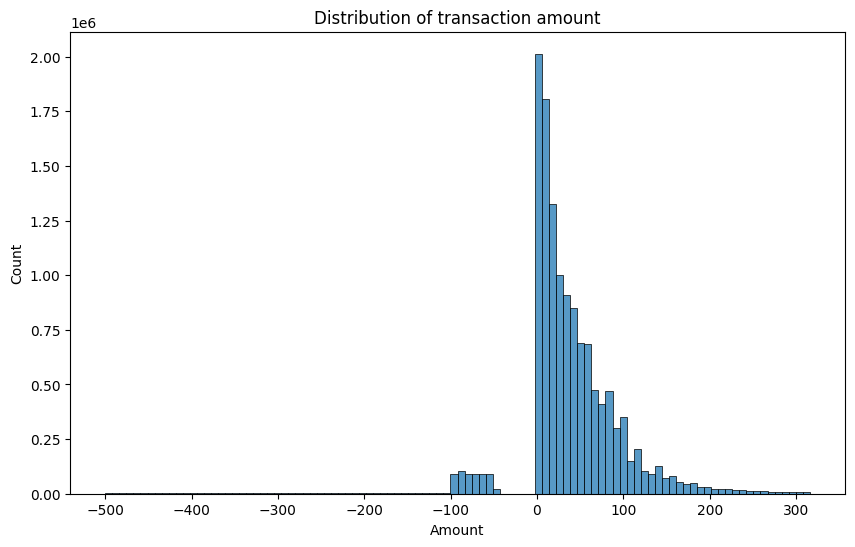

In [ ]:
# Такой же график, но без выбросов - транзакций с большими суммами
q99 = data['amount'].quantile(0.99)
plt.figure(figsize=(10, 6))
sns.histplot(data=data[data['amount'] <= q99], x='amount', bins=100)
plt.title('Distribution of transaction amount')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()

Вывод по графику :
1. Сильная асимметрия вправо даже после отсечения выбросов(переводов больших сумм)
2. Лучше видны отрицательные значения(возвраты/отмены операций/ошибки данных)

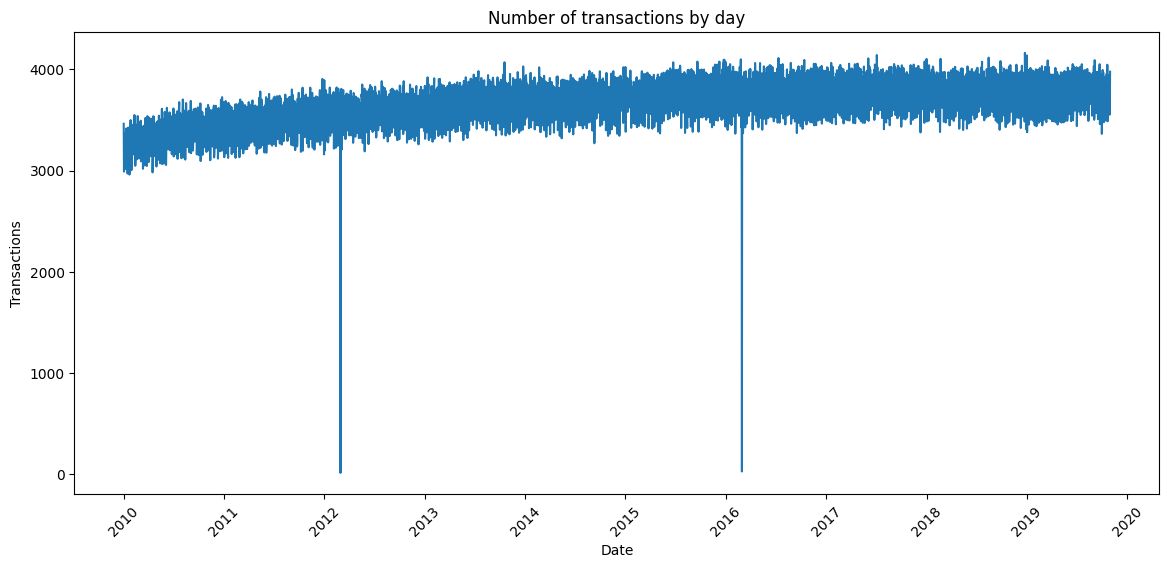

In [ ]:
# Количество транзакций по дням
daily_tx = (data.groupby(data['date'].dt.date).agg(transactions=('id','count'),total_amount=('amount','sum')).reset_index())

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_tx, x='date', y='transactions')
plt.title('Number of transactions by day')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(rotation=45)
plt.show()

Вывод по графику :
1. Общий восходящий тренд(небольшое замедленее с 2016)
2. Регулярные колебания(сезонность или календарный эффект)
3. Очень сильные провалы почти до нуля(возможно, ошибки в системе)
4. Общий уровень ряда стабилен(без резких скачков/обвалов/анамального роста в конце периода)

<!--  -->

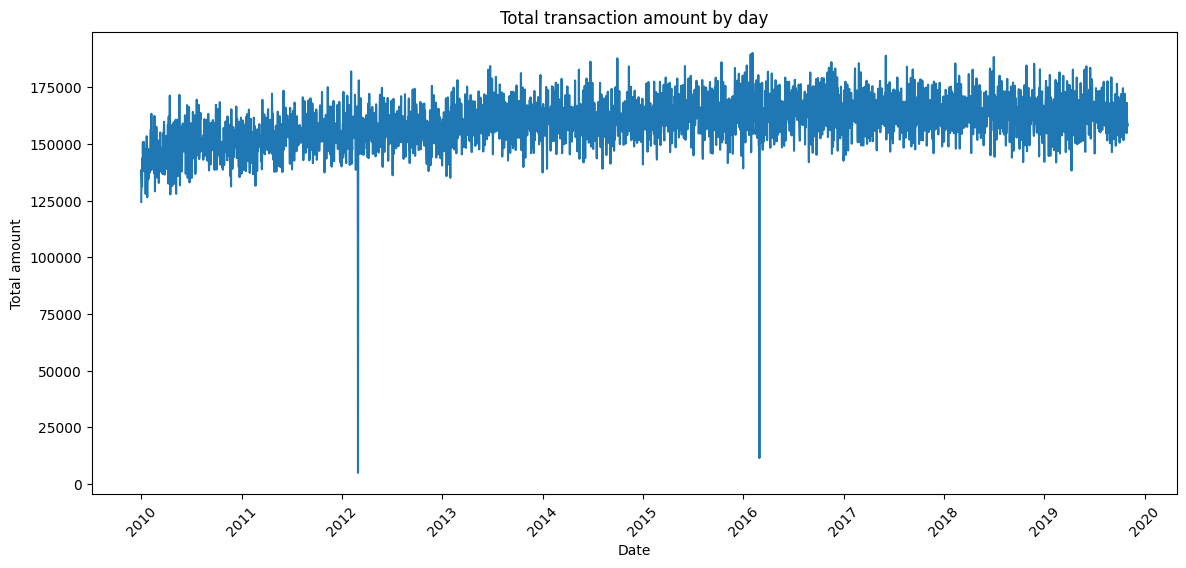

In [ ]:
# Общая сумма транзакций по дням
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_tx, x='date', y='total_amount')
plt.title('Total transaction amount by day')
plt.xlabel('Date')
plt.ylabel('Total amount')
plt.xticks(rotation=45)
plt.show()

Вывод по графику :
1. Общий тренд - рост оборота(с 2010 по 2016 заметен рост)
2. Высокий "шум"(значительные краткосрочные колебания)
3. Аномальные провалы как и на прошлом графике
4. Стабильный диапазон после 2016
5. Нет резких "скачков вверх" и отсутствует явный экспоненциальный рост

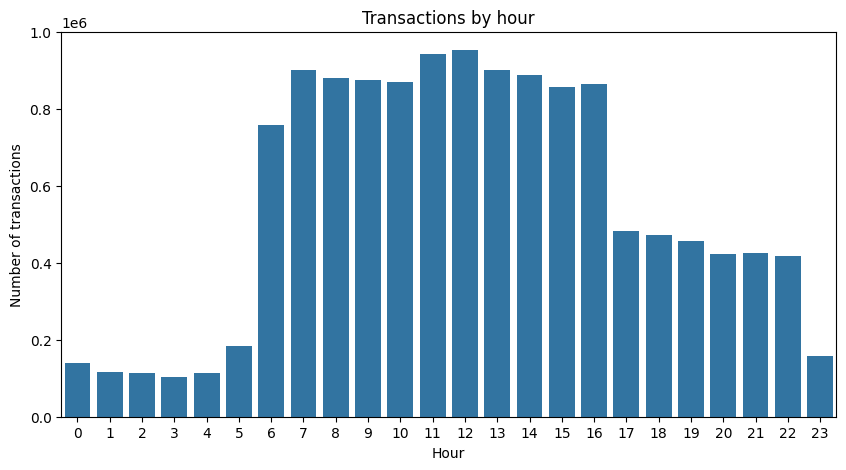

In [ ]:
# Транзакции по часам
hourly = (data.groupby('hour').agg(transactions=('id', 'count'),total_amount=('amount', 'sum')).reset_index())

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly, x='hour', y='transactions')
plt.title('Transactions by hour')
plt.xlabel('Hour')
plt.ylabel('Number of transactions')
plt.show()

Вывод по графику :
1. Минимальная активность с 23 до 5
2. Резкий рост утром(с 6 часов)
3. Пик активности днём(в 12 часов)
4. Плавное снижение после обеда(после 14 часов)
5. Явный суточный паттерн по промежуткам времени(поведение "офисного" типа)

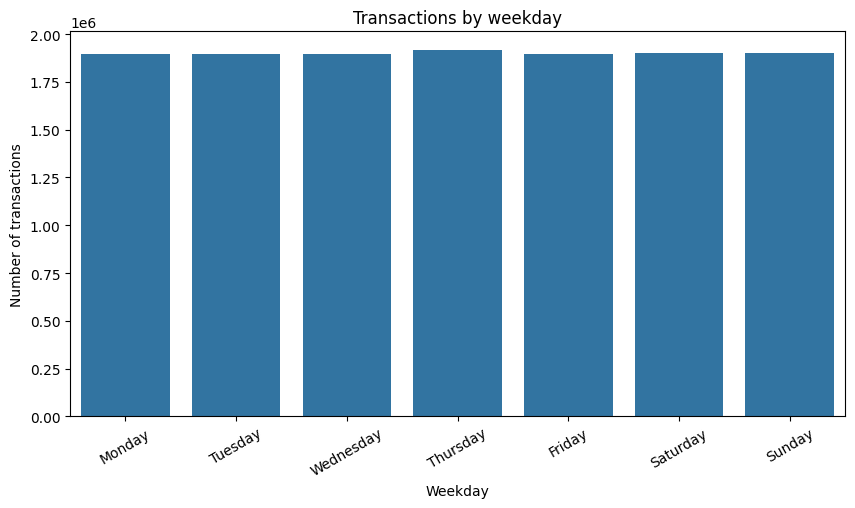

In [ ]:
# Транзакции по дням недели
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_stats = (data.groupby('weekday').agg(transactions=('id','count')).reset_index())

weekday_stats['weekday'] = pd.Categorical(weekday_stats['weekday'], categories=weekday_order, ordered=True)
weekday_stats = weekday_stats.sort_values('weekday')

plt.figure(figsize=(10, 5))
sns.barplot(data=weekday_stats, x='weekday', y='transactions')
plt.title('Transactions by weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of transactions')
plt.xticks(rotation=30)
plt.show()

Вывод по графику :
1. Отсутствие недельной сезонности
2. Нет "эффекта выходных"(или "пятницы")

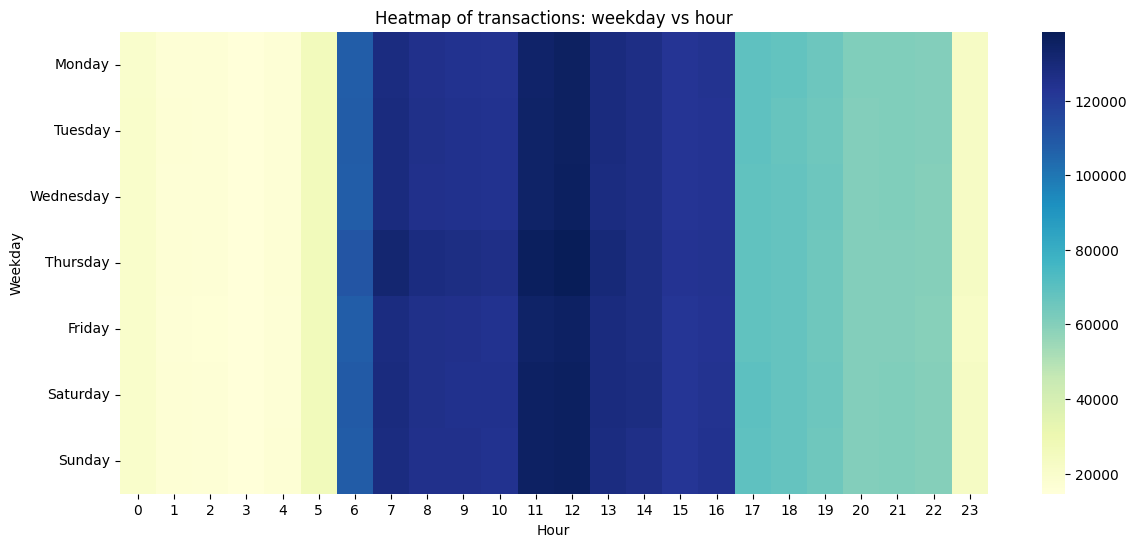

In [ ]:
# Heatmap: день недели × час
heatmap_data = pd.pivot_table(data, values='id',index='weekday',columns='hour',aggfunc='count')

heatmap_data = heatmap_data.reindex(weekday_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu')
plt.title('Heatmap of transactions: weekday vs hour')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()

Вывод по графику :
1. Ярко выраженный суточный паттерн(как и в предыдущем графике)
2. Пик активности стабильно днём
3. Очень слабая зависимость от дня недели
4. Сильная регулярность(легко выявить аномалии)

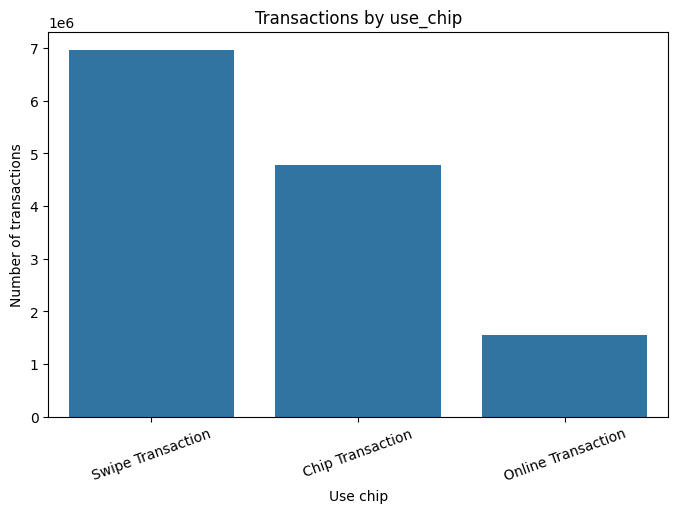

In [ ]:
# Кол-во транзакций по типу использования карты
# Swipe Transaction - оплата с «протяжкой» карты через магнитную полосу
# Chip Transaction - оплата по чипу
# Online Transaction - онлайн-транзакция
chip_stats = data['use_chip'].value_counts().reset_index()
chip_stats.columns = ['use_chip', 'transactions']

plt.figure(figsize=(8, 5))
sns.barplot(data=chip_stats, x='use_chip', y='transactions')
plt.title('Transactions by use_chip')
plt.xlabel('Use chip')
plt.ylabel('Number of transactions')
plt.xticks(rotation=20)
plt.show()

Вывод по графику :
1. Данные "старого типа"(карты с магнитной полосой чаще используются, чем карты с чипом)
2. Высокий риск мошеннических транзакций

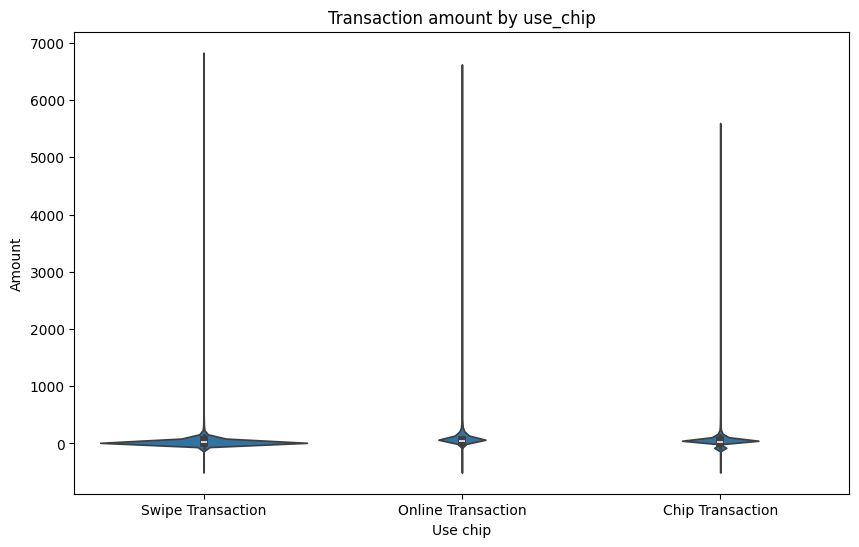

In [ ]:
# суммы по use_chip
plt.figure(figsize=(10, 6))
# sns.boxplot(data=data, x='use_chip', y='amount')
sns.violinplot(data=data, x='use_chip', y='amount')
plt.title('Transaction amount by use_chip')
plt.xlabel('Use chip')
plt.ylabel('Amount')
plt.show()

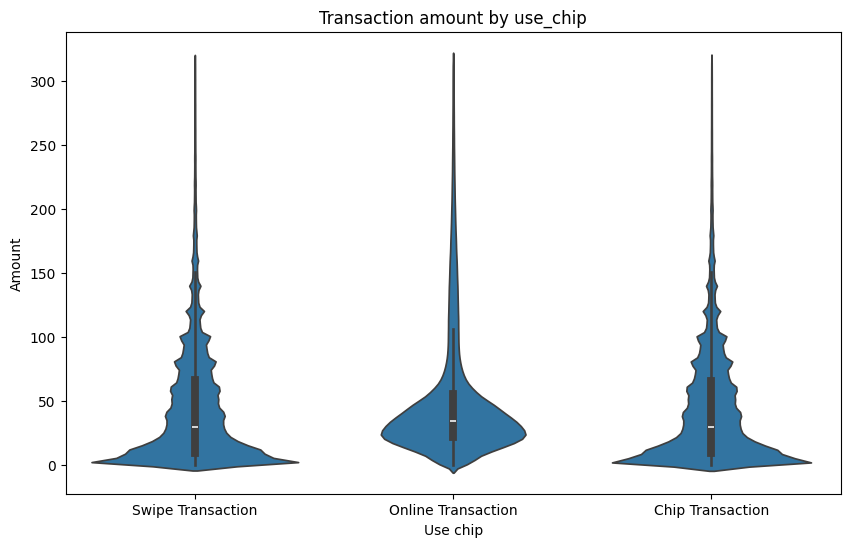

In [ ]:
# суммы по use_chip, но без аномальных значений
q99 = data['amount'].quantile(0.99)
# df_f = data[data['amount'] <= q99]
df_f = data[(data['amount'] <= q99) & (data['amount'] > 0)]  # убираем выбросы и отрицательные значения(возврат средств)

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_f, x='use_chip', y='amount')
plt.title('Transaction amount by use_chip')
plt.xlabel('Use chip')
plt.ylabel('Amount')
plt.show()

Вывод по графику :
1. Online транзакции - более "сконцентрированные"(имеют более стабильный и предсказуемый размер)
2. Swipe и Chip - более "размазанные"(широкий диапазон значений)

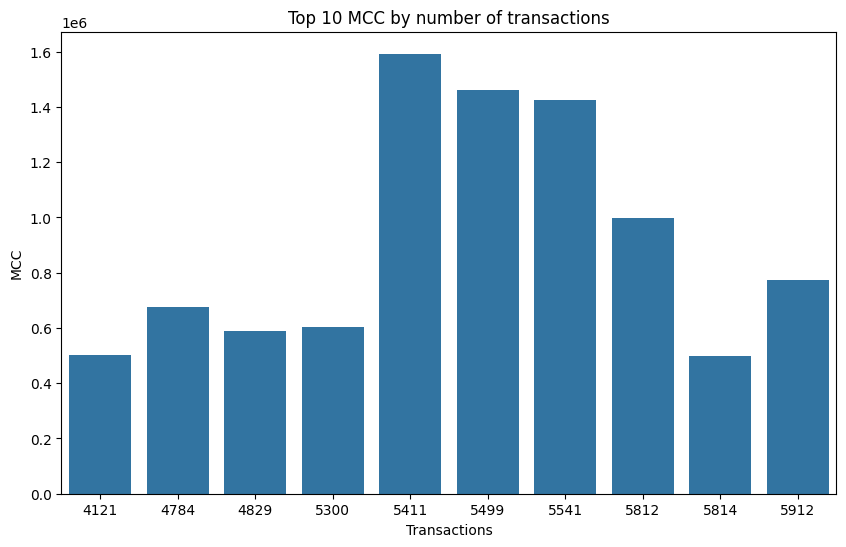

In [ ]:
# mcc - стандартный 4-значный код, для обозначения типа бизнеса
# data['mcc'].value_counts().head(10) - топ10 самых популярных
top_mcc = data['mcc'].value_counts().head(10).index
mcc_tx = (data[data['mcc'].isin(top_mcc)].groupby('mcc').agg(transactions=('id','count'))
          .reset_index().sort_values('transactions',ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(data=mcc_tx, x='mcc', y='transactions')
# sns.barplot(data=mcc_tx, x='transactions', y='mcc')
plt.title('Top 10 MCC by number of transactions')
plt.xlabel('Transactions')
plt.ylabel('MCC')
plt.show()

Вывод по графику :
1. Значительная разница между категориями
2. Продукты - главный лидер транзакций(5411, 5499)
3. Регулярные расходы(бензин(5541) и рестораны(5812))
* MCC	    Тип бизнеса
* 5411	Grocery Stores (продукты)
* 5499	Food Stores (прочие продукты)
* 5541	Gas Stations (АЗС)
* 5812	Restaurants
* 5814	Fast Food
* 4784	Tolls / Transport
* 4829	Money Transfer
* 5300	Wholesale Clubs
* 5912	Drug Stores
* 4121	Taxi

In [ ]:
data['mcc'].value_counts().head(10)

mcc
5411    1592584
5499    1460875
5541    1424711
5812     999738
5912     772913
4784     674135
5300     601942
4829     589140
4121     500662
5814     499659
Name: count, dtype: int64

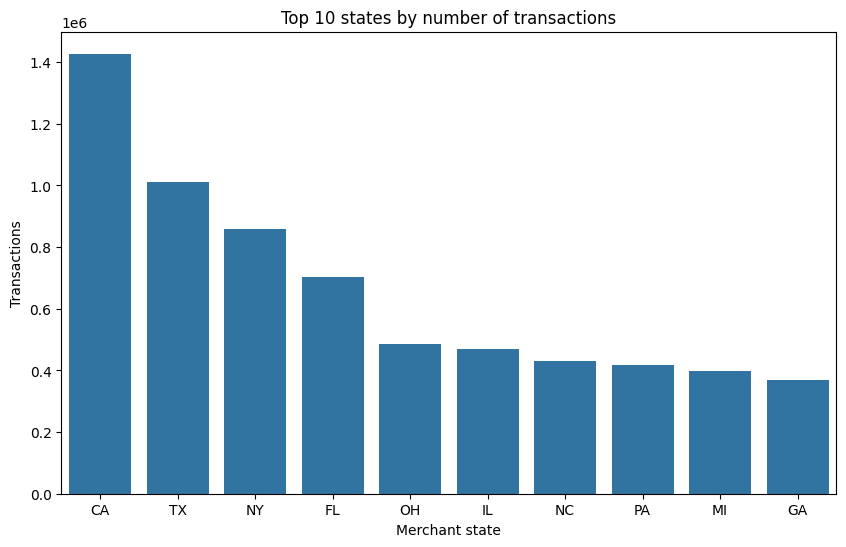

In [ ]:
# Топ штатов по числу транзакций
df_states = data[data['merchant_state'] != 'None_flag']
top_states = df_states['merchant_state'].value_counts().head(10).index
# подсчет транзакций
state_tx = (df_states[df_states['merchant_state'].isin(top_states)].groupby('merchant_state').agg(transactions=('id', 'count')).reset_index().sort_values('transactions', ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(data=state_tx, x='merchant_state', y='transactions')
plt.title('Top 10 states by number of transactions')
plt.xlabel('Merchant state')
plt.ylabel('Transactions')
plt.show()

Вывод по графику :
1. Транзакционная активность сильно зависит от географии(транзакционная активность сильно зависит от географии)
2. Распределение транзакций коррелирует с численностью населения и экономической активностью штатов
3. Значительная часть транзакций сосредоточена в небольшом числе штатов

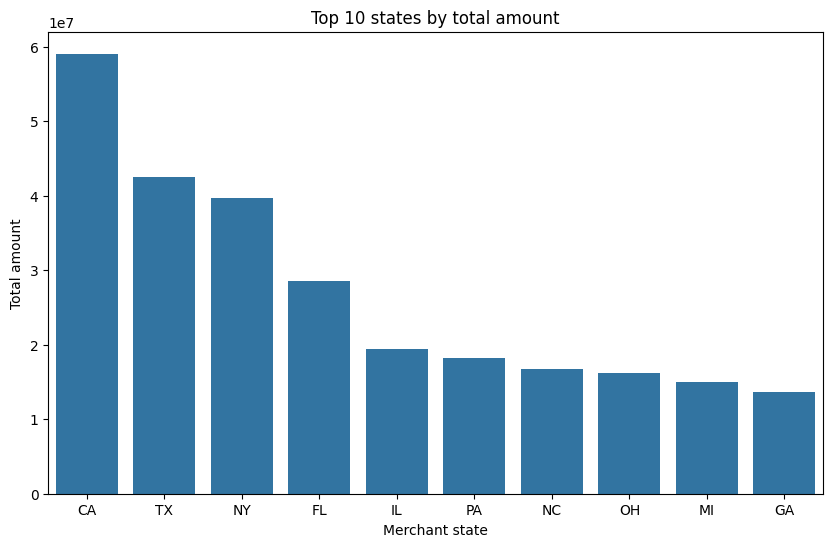

In [ ]:
# Топ штатов по сумме транзакций
state_amount = (
    data.assign(merchant_state=data['merchant_state'])
    .query("merchant_state in @top_states")
    .groupby('merchant_state')
    .agg(total_amount=('amount', 'sum'))
    .reset_index()
    .sort_values('total_amount', ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(data=state_amount, x='merchant_state', y='total_amount')
plt.title('Top 10 states by total amount')
plt.xlabel('Merchant state')
plt.ylabel('Total amount')
plt.show()

Совокупный вывод с прошлым графиком:
1. Лидеры по количеству и лидеры по деньгам одни и те же
2. Отсутствуют "скрытые дорогие" штаты(меньше транзакций, но больше по кол-ву денег)
3. Общий объём транзакций в первую очередь определяется количеством операций
Выводы для бинеса:
1. Очевидны основные рынки
2. География играет большую роль

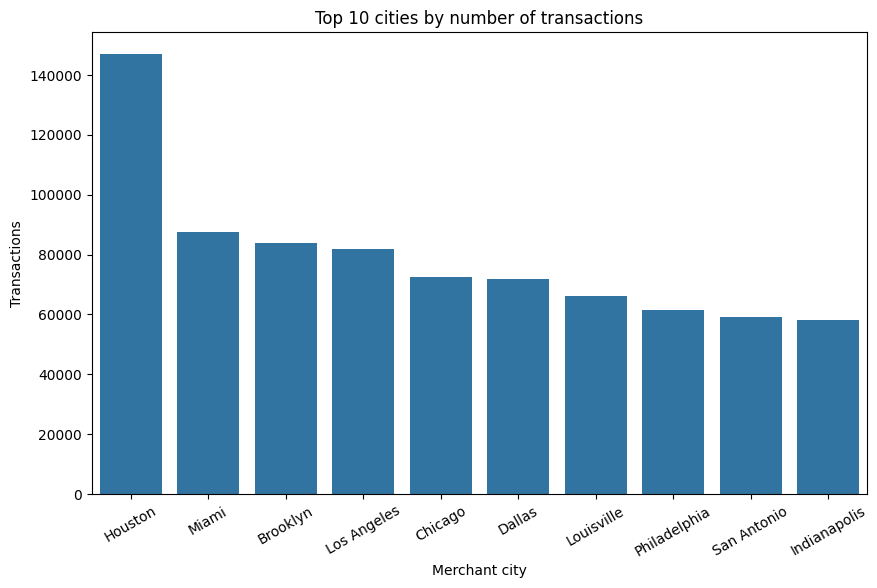

In [ ]:
# Топ городов по числу транзакций без статуса Online
df_city = data[data['merchant_city'] != 'ONLINE']
top_cities = df_city['merchant_city'].value_counts().head(10).index
city_tx = (df_city[df_city['merchant_city'].isin(top_cities)].groupby('merchant_city').agg(transactions=('id', 'count')).reset_index().sort_values('transactions', ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(data=city_tx, x='merchant_city', y='transactions')
plt.title('Top 10 cities by number of transactions')
plt.xlabel('Merchant city')
plt.ylabel('Transactions')
plt.xticks(rotation=30)
plt.show()

Вывод по графику :
1. Распределение неравномерное, но без "обрыва"(есть лидер, но далее плавное снижение)
2. Один город сильно выделяется(концентрация активности в конкретной географической точке)
3. Лидер в городе и в штате разный
4. Возможный эффект бизнеса/партнёров(больше бизнес точек/особенностей данных/партнёрской сети)

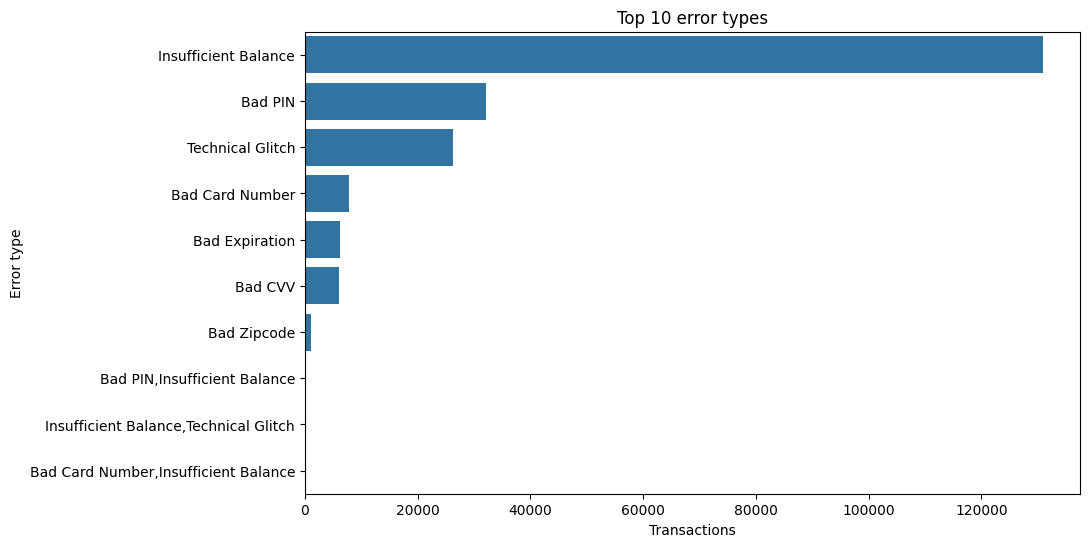

In [ ]:
# Топ ошибок
top_errors = (
    data.loc[(~data['errors'].isin(['No_errors'])) & (data['errors'].notna()) & (data['errors'].count() > 0), 'errors']
    .value_counts().head(10).reset_index())
top_errors.columns = ['error_type', 'transactions']
plt.figure(figsize=(10, 6))
sns.barplot(data=top_errors, x='transactions', y='error_type')
plt.title('Top 10 error types')
plt.xlabel('Transactions')
plt.ylabel('Error type')
plt.show()

Вывод по графику :
1. Основная причина неуспешных транзакций - недостаточность средств на счёте
2. Существенная доля отказов связана с ошибками аутентификации со стороны клиента(неверный PIN-код)
3. Часть ошибок связана не с клиентом и не с балансом, а с техническими проблемами системы или канала обработки транзакции
4. Мало комбинированных ошибок(не очень ясна их природа логирования в БД)

In [ ]:
data['errors'].value_counts().head(10)

errors
No_errors                                13094522
Insufficient Balance                       130902
Bad PIN                                     32119
Technical Glitch                            26271
Bad Card Number                              7767
Bad Expiration                               6161
Bad CVV                                      6106
Bad Zipcode                                  1126
Bad PIN,Insufficient Balance                  293
Insufficient Balance,Technical Glitch         243
Name: count, dtype: int64

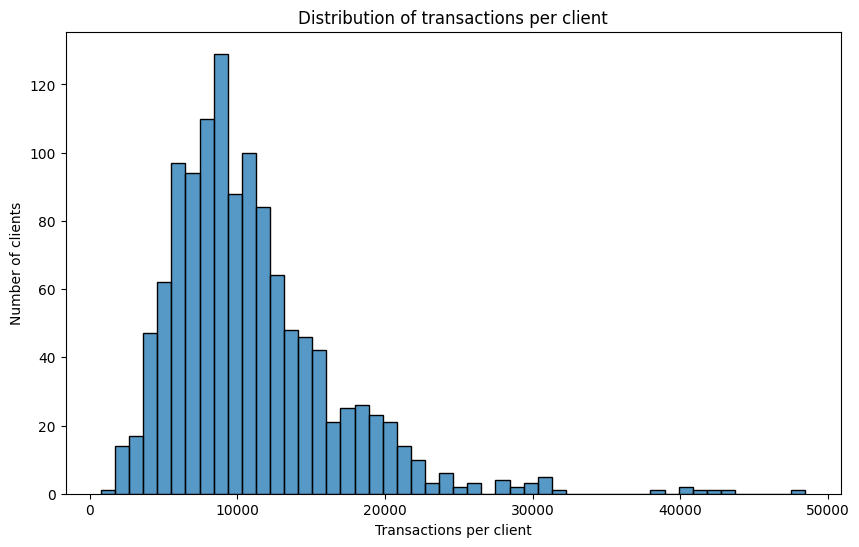

In [ ]:
# Количество транзакций у по клиентам
client_tx = (data.groupby('client_id').agg(n_transactions=('id', 'count')).reset_index())
plt.figure(figsize=(10, 6))
sns.histplot(data=client_tx, x='n_transactions', bins=50)
plt.title('Distribution of transactions per client')
plt.xlabel('Transactions per client')
plt.ylabel('Number of clients')
plt.show()

Вывод по графику :
1. Основная масса клиентов в диапазоне 4k-15k транзакций
2. Есть "суперактивные" клиенты(острова в диапазоне 27к-32к и 38к-44к)
3. Среднее ≠ типичный клиент
4. Есть потенциальные аномалии(38к-50к, возможно, бизнес клиенты или аномалии, или ошибки)

**Обработка остальных таблиц**

In [ ]:
# merge всех таблиц
# df = data.copy()

In [ ]:
data_fraud_labels[['id', 'fraud_flag']].info()
# data_fraud_labels['id'].duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   id          int64 
 1   fraud_flag  object
dtypes: int64(1), object(1)
memory usage: 136.0+ MB


In [ ]:
cards_data.columns.to_list()
# cards_data['id'].duplicated().sum()

['id',
 'client_id',
 'card_brand',
 'card_type',
 'card_number',
 'expires',
 'cvv',
 'has_chip',
 'num_cards_issued',
 'credit_limit',
 'acct_open_date',
 'year_pin_last_changed',
 'card_on_dark_web']

In [ ]:
users_data[['id']].info()
# users_data['id'].duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2000 non-null   int64
dtypes: int64(1)
memory usage: 15.8 KB


In [ ]:
data_mcc_codes[['mcc']].info()
# data_mcc_codes['mcc'].duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   mcc     109 non-null    int64
dtypes: int64(1)
memory usage: 1004.0 bytes


In [ ]:
# merge всех таблиц
# 1. merge один(id) к одному(id) к таблице data_fraud_labels
data = data.merge(
    data_fraud_labels,
    on='id',
    how='left',
    validate='one_to_one'
)

In [ ]:
# 2. merge многие(mcc из data) к одному(mcc из data_mcc_codes) к таблице data_mcc_codes
data = data.merge(
    data_mcc_codes,
    on='mcc',
    how='left',
    validate='many_to_one'
)

In [ ]:
# 3. merge многие(id из data) к одному(id из cards_data) к таблице cards_data
# номер карты привязан к транзакции
cards = cards_data.copy().rename(columns={'id': 'card_id_ref'})
data = data.merge(
    cards,
    left_on='card_id',
    right_on='card_id_ref',
    how='left',
    validate='many_to_one'
)

In [ ]:
# 4. merge многие(id из data) к одному(id из users_data) к таблице users_data
# del df["client_id_y"]
users = users_data.copy().rename(columns={'id': 'user_id_ref'})
data = data.merge(
    users,
    left_on='client_id_x',
    right_on='user_id_ref',
    how='left',
    validate='many_to_one'
)

In [ ]:
# проверка корректности данных(нет новых строк)
fp_shape[0] == data.shape[0]

True

In [ ]:
# Fraud по времени
mask = data['fraud_flag'].notna()
data.loc[mask, 'fraud_bin'] = data.loc[mask, 'fraud_flag'].map({'No': 0, 'Yes': 1})

print('Доля строк с fraud-разметкой:', round(mask.mean(), 3))
print()
print(data.loc[mask, 'fraud_flag'].value_counts(dropna=False))
print()
print('Fraud rate по размеченным данным:', round(data.loc[mask, 'fraud_bin'].mean(), 6))

Доля строк с fraud-разметкой: 0.67

fraud_flag
No     8901631
Yes      13332
Name: count, dtype: int64

Fraud rate по размеченным данным: 0.001495


In [ ]:
# Fraud rate по часам
'''
1. Формирование размеченных транзакций по часам
2. Подсчет для каждого часа общего кол-ва операций(мошеннических и их доля)
3. Формирование таблицы с метриками по каждому часу за сутки, включая процент мошенничества
'''
fraud_by_hour = (data.loc[mask].groupby('hour')
     .agg(transactions=('id', 'count'),
        fraud_count=('fraud_bin', 'sum'),
        fraud_rate=('fraud_bin', 'mean')
    ).reset_index())

fraud_by_hour['fraud_rate_pct'] = fraud_by_hour['fraud_rate'] * 100
fraud_by_hour

,hour,transactions,fraud_count,fraud_rate,fraud_rate_pct
0,0,94170,13.0,0.000138,0.013805
1,1,77322,38.0,0.000491,0.049145
2,2,75384,38.0,0.000504,0.050409
3,3,69297,107.0,0.001544,0.154408
4,4,77190,143.0,0.001853,0.185257
5,5,122510,242.0,0.001975,0.197535
6,6,508053,455.0,0.000896,0.089558
7,7,604388,541.0,0.000895,0.089512
8,8,590388,530.0,0.000898,0.089771
9,9,587241,856.0,0.001458,0.145766


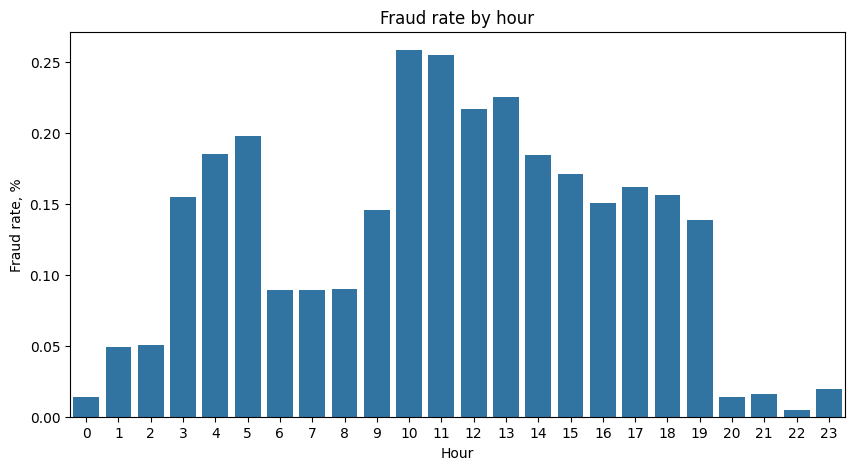

In [ ]:
# Доля мошеннических транзакций от часа
plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_by_hour, x='hour', y='fraud_rate_pct')
plt.title('Fraud rate by hour')
plt.xlabel('Hour')
plt.ylabel('Fraud rate, %')
plt.show()

Вывод по графику :
1. Мошенничество с выраженной временной зависимостью и не распределён равномерно в течение суток(при условии, что данные распределены корректно)
2. Пик часов мошенничества: с 10 до 13
3. Утренний рост(с 3 по 5 - хороший идентификатор мошенничества)

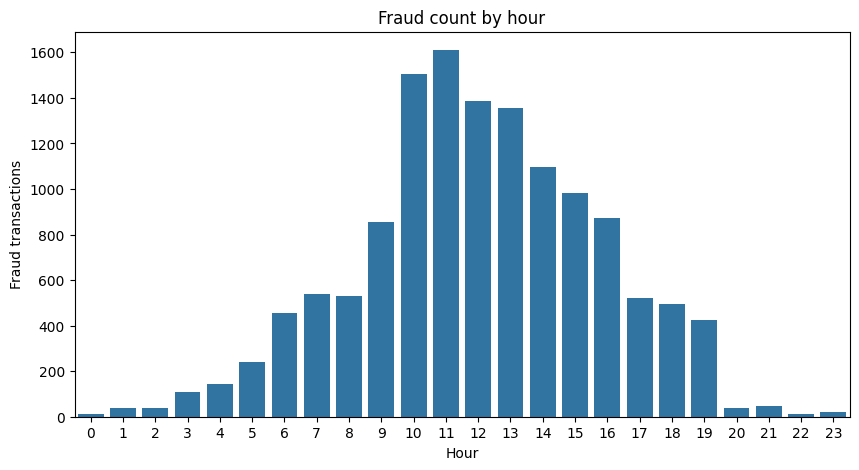

In [ ]:
# Кол-во мошеннических транзакций от часа
plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_by_hour, x='hour', y='fraud_count')
plt.title('Fraud count by hour')
plt.xlabel('Hour')
plt.ylabel('Fraud transactions')
plt.show()

Вывод по графику :
1. Наибольшее количество мошеннических транзакций видно в дневные часы(с 10 до 13), что совпадает с общим пиком транзакционной активности
2. Ночью количество мошенничества минимально(может быть связано с низким общим объёмом операций). Для верной оценки риска нужно анализировать и долю мошеннических транзакций

In [ ]:
'''
1. Группировка размеченных транзакций по дням недели
2. Подсчет общего числа операций для каждого дня(кол-во мошеннических транзакций и их доли)
3. fraud_by_weekday - упорядоченная по дням недели таблица с метриками
4. fraud_rate_pct - процент мошенничества для каждого дня
'''
fraud_by_weekday = (
    data.loc[mask]
    .groupby('weekday')
    .agg(
        transactions=('id', 'count'),
        fraud_count=('fraud_bin', 'sum'),
        fraud_rate=('fraud_bin', 'mean')
    )
    .reset_index()
)

fraud_by_weekday['weekday'] = pd.Categorical(
    fraud_by_weekday['weekday'],
    categories=weekday_order,
    ordered=True
)

fraud_by_weekday = fraud_by_weekday.sort_values('weekday')
fraud_by_weekday['fraud_rate_pct'] = fraud_by_weekday['fraud_rate'] * 100

fraud_by_weekday

,weekday,transactions,fraud_count,fraud_rate,fraud_rate_pct
1,Monday,1271161,1747.0,0.001374,0.137433
5,Tuesday,1270976,2037.0,0.001603,0.160271
6,Wednesday,1271177,1102.0,0.000867,0.086691
4,Thursday,1285101,2082.0,0.001620,0.162011
0,Friday,1269809,2284.0,0.001799,0.179870
2,Saturday,1273868,1434.0,0.001126,0.112571
3,Sunday,1272871,2646.0,0.002079,0.207877


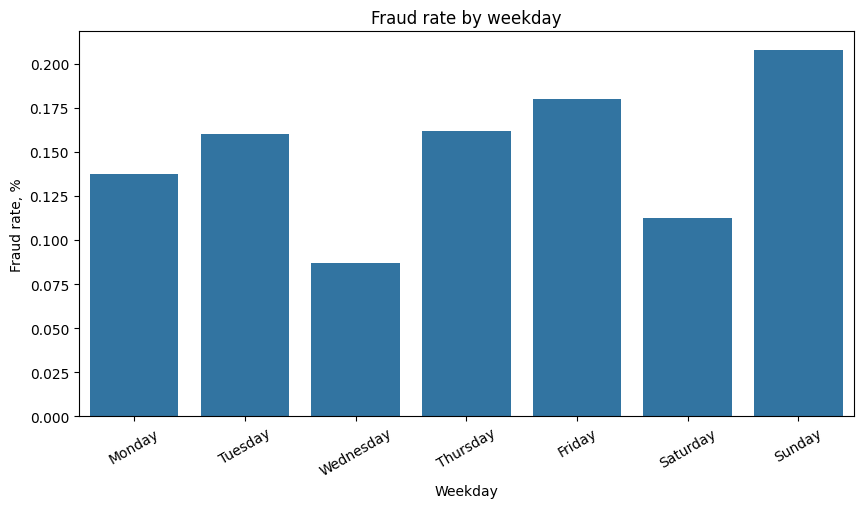

In [ ]:
# Доля мошеннических транзакций от дня недели
plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_by_weekday, x='weekday', y='fraud_rate_pct')
plt.title('Fraud rate by weekday')
plt.xlabel('Weekday')
plt.ylabel('Fraud rate, %')
plt.xticks(rotation=30)
plt.show()

Вывод по графику :
1. Доля мошеннических транзакций варьируется по дням недели(макс. в воскресенье(20-21%) и мин. в среду(8-9%))
2. Наличие временных паттернов мошенничества(видна растущая тенденция, но среда и суббота выбивются), особенно выраженных в конце недели( возможно, связано с изменением пользовательского поведения и логированием транзакций)

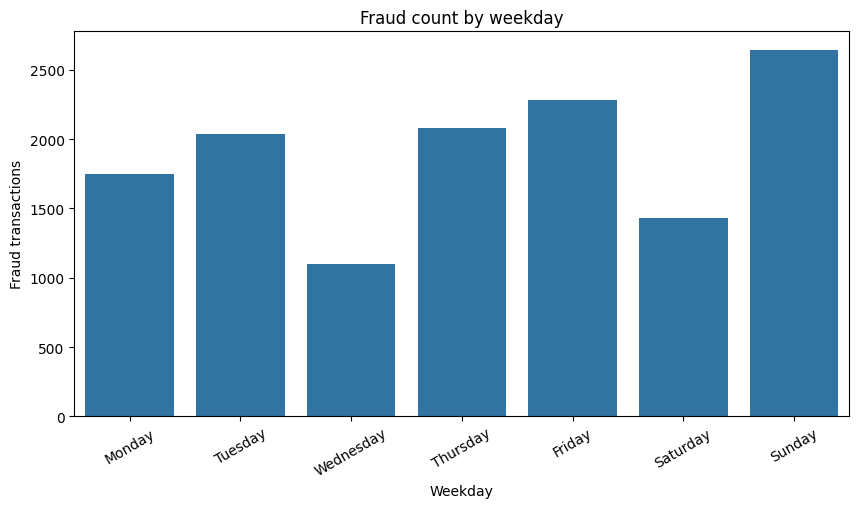

In [ ]:
# Кол-во мошеннических транзакций от дня недели
plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_by_weekday, x='weekday', y='fraud_count')
plt.title('Fraud count by weekday')
plt.xlabel('Weekday')
plt.ylabel('Fraud transactions')
plt.xticks(rotation=30)
plt.show()

Вывод по графику :
1. Кол-во мошеннических транзакций увеличивается к концу недели(видна растущая тенденция, но среда и суббота выбивются) и достигает максимума в воскресенье
2. Совпадение высокого fraud_count и fraud_rate в воскресенье указывает на повышенный риск мошенничества в этот день

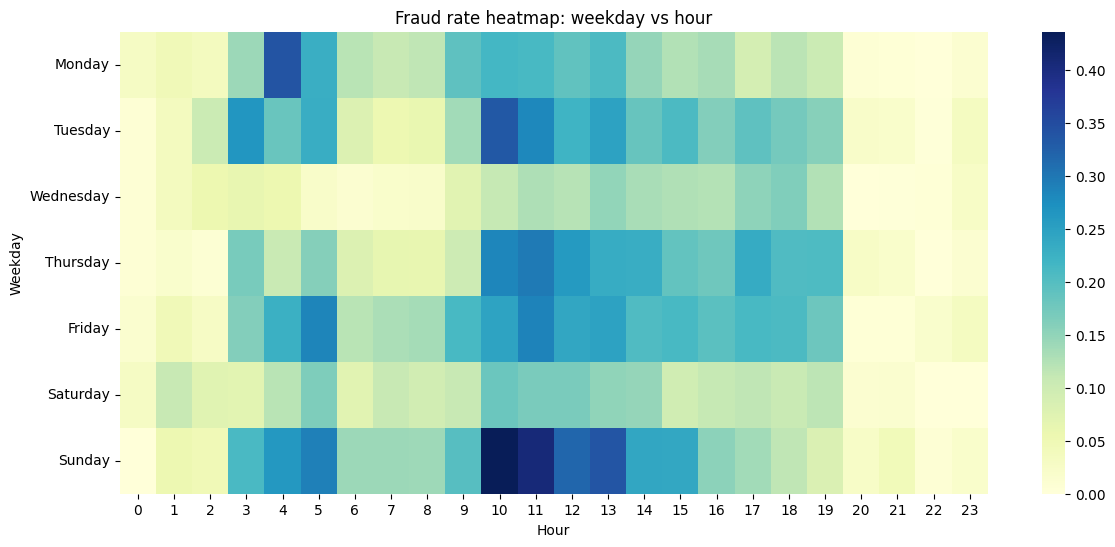

In [ ]:
# Доля мошеннических транзакций зависящая одновременно от дня недели и часа
heatmap_fraud_rate = pd.pivot_table(
    data.loc[mask],
    values='fraud_bin',
    index='weekday',
    columns='hour',
    aggfunc='mean'
)

heatmap_fraud_rate = heatmap_fraud_rate.reindex(weekday_order)
heatmap_fraud_rate_pct = heatmap_fraud_rate * 100

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_fraud_rate_pct, cmap='YlGnBu', annot=False)
plt.title('Fraud rate heatmap: weekday vs hour')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()

Вывод по графику :
1. Мошенническая активность имеет выраженные временные паттерны, зависящие от сочетания дня недели и часа суток
2. Максимальный риск наблюдается в дневные часы(с 10 до 13), тогда как вечерние часы и середина недели характеризуются минимальным уровнем мошенничества

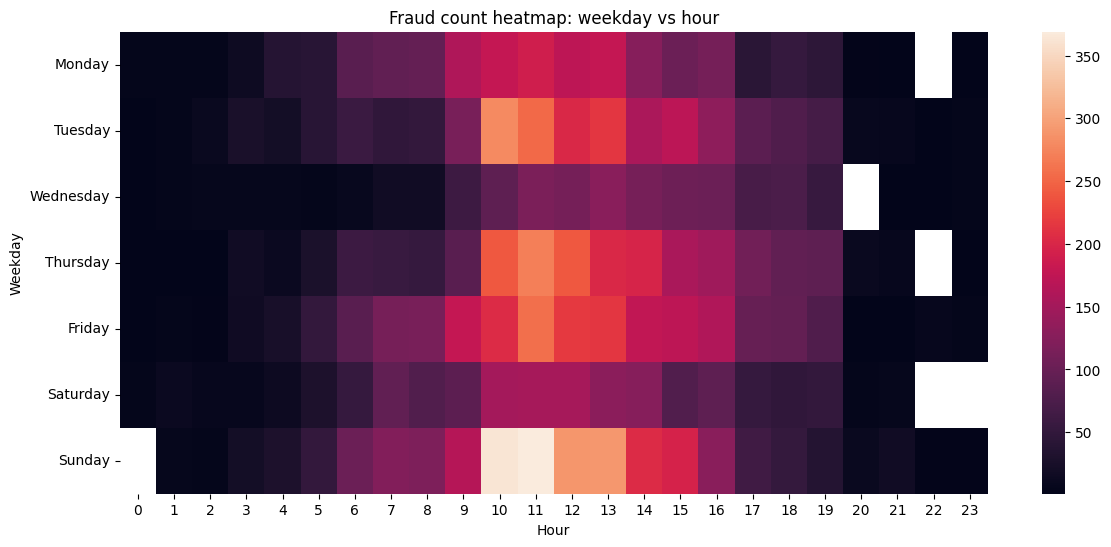

In [ ]:
# Количество мошеннических транзакций зависящая от дня недели и часа суток
heatmap_fraud_count = pd.pivot_table(
    data.loc[mask & (data['fraud_bin'] == 1)],
    values='id',
    index='weekday',
    columns='hour',
    aggfunc='count'
)

heatmap_fraud_count = heatmap_fraud_count.reindex(weekday_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_fraud_count, annot=False)
plt.title('Fraud count heatmap: weekday vs hour')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()

Вывод по графику :
1. Максимальный риск наблюдается в дневные часы(с 10 до 13), тогда как вечерние часы и середина недели характеризуются минимальным уровнем мошенничества
2. Совпадение пиков по количеству и доле(предыдущий график) мошенничества указывает на наличие устойчивых временных паттернов fraud-активности

In [ ]:
# Сводная таблица с 4 временными интервалами
'''
1. Подсчет транзакций
2. Подсчет сколько из них мошеннических
3. Подсчет доли мошеннических транзакций
'''
def hour_group(hour):
    if 0 <= hour <= 5:
        return 'Night'
    elif 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Day'
    else:
        return 'Evening'

data['hour_group'] = data['hour'].apply(hour_group)

fraud_by_hour_group = (
    data.loc[mask]
    .groupby('hour_group')
    .agg(
        transactions=('id', 'count'),
        fraud_count=('fraud_bin', 'sum'),
        fraud_rate=('fraud_bin', 'mean')
    )
    .reset_index()
)

hour_group_order = ['Night', 'Morning', 'Day', 'Evening']
fraud_by_hour_group['hour_group'] = pd.Categorical(
    fraud_by_hour_group['hour_group'],
    categories=hour_group_order,
    ordered=True
)
fraud_by_hour_group = fraud_by_hour_group.sort_values('hour_group')
fraud_by_hour_group['fraud_rate_pct'] = fraud_by_hour_group['fraud_rate'] * 100

fraud_by_hour_group

,hour_group,transactions,fraud_count,fraud_rate,fraud_rate_pct
3,Night,515873,581.0,0.001126,0.112625
2,Morning,3506327,5499.0,0.001568,0.156831
0,Day,3315248,6215.0,0.001875,0.187467
1,Evening,1577515,1037.0,0.000657,0.065736


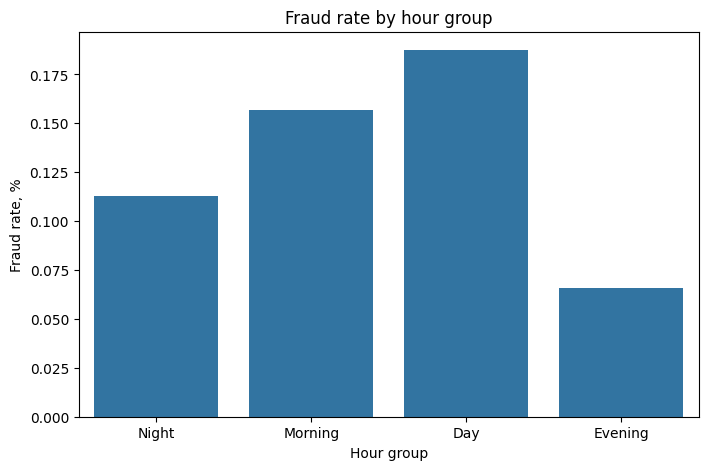

In [ ]:
# Доля мошеннических транзакций от времени суток
plt.figure(figsize=(8, 5))
sns.barplot(data=fraud_by_hour_group, x='hour_group', y='fraud_rate_pct')
plt.title('Fraud rate by hour group')
plt.xlabel('Hour group')
plt.ylabel('Fraud rate, %')
plt.show()

Вывод по графику :
1. Моешенничество не максимально ночью, а смещён в дневную активность пользователей

In [ ]:
# Мини-таблицы для выводов
print('Топ-5 часов по fraud rate:')
display(fraud_by_hour.sort_values('fraud_rate', ascending=False).head(5))

print('Топ-5 часов по количеству fraud:')
display(fraud_by_hour.sort_values('fraud_count', ascending=False).head(5))

print('Дни недели по fraud rate:')
display(fraud_by_weekday.sort_values('fraud_rate', ascending=False))

Топ-5 часов по fraud rate:


,hour,transactions,fraud_count,fraud_rate,fraud_rate_pct
10,10,583779,1507.0,0.002581,0.258146
11,11,632478,1610.0,0.002546,0.254554
13,13,603566,1357.0,0.002248,0.224830
12,12,638906,1386.0,0.002169,0.216933
5,5,122510,242.0,0.001975,0.197535


Топ-5 часов по количеству fraud:


,hour,transactions,fraud_count,fraud_rate,fraud_rate_pct
11,11,632478,1610.0,0.002546,0.254554
10,10,583779,1507.0,0.002581,0.258146
12,12,638906,1386.0,0.002169,0.216933
13,13,603566,1357.0,0.002248,0.224830
14,14,595187,1096.0,0.001841,0.184144


Дни недели по fraud rate:


,weekday,transactions,fraud_count,fraud_rate,fraud_rate_pct
3,Sunday,1272871,2646.0,0.002079,0.207877
0,Friday,1269809,2284.0,0.001799,0.179870
4,Thursday,1285101,2082.0,0.001620,0.162011
5,Tuesday,1270976,2037.0,0.001603,0.160271
1,Monday,1271161,1747.0,0.001374,0.137433
2,Saturday,1273868,1434.0,0.001126,0.112571
6,Wednesday,1271177,1102.0,0.000867,0.086691


Вывод по мини-таблицам:
1. Мошеннические транзакции распределены по времени неравномерно(наиболее высокая доля мошеннических транзакций наблюдается в 10:00 - 13:00, а максимальное число в 11:00
2. По дням недели наибольший риск мошенничества приходится на воскресенье, тогда как среда является наименее рискованным днём
3. Выделяется 05:00 как интервал с повышенной долей мошенничества при сравнительно меньшем числе транзакций

Финальный вывод по проекту:
1. Доля мошеннических транзакций максимальна в дневные часы и постепенно снижается к вечеру
2. Следовательно, мошенническая активность синхронизирована с общей пользовательской активностью, а не сосредоточена исключительно в ночное время